# Research02 Generate Data
 
 이 노트북은 Research03 이후 실험에서 사용할 생성 anomaly window를 만든다.
 
 생성 방식은 네 가지다.
 
 ```text
 GT-GAN / Diffusion:
 random noise에서 전체 anomaly window 생성
 
 Masking GT-GAN / Masking Diffusion:
 real anomaly seed window를 기반으로 data-driven adaptive temporal block + feature-group masking을 적용하고,
 관측된 seed 값은 유지한 채 masked time/feature region만 복원하여 생성
 ```
 
 따라서 masking 기반 생성은 더 이상 element-wise random masking이 아니라, 정상-이상 차이가 큰 시간 구간과 feature 상관/차이를 반영한 adaptive structured masking 방식이다.


## 1. Research02의 역할
 
 전체 실험 흐름은 다음과 같다.
 
 ```text
 Research01:
 real normal + real anomaly seed
 => RandomForestClassifier baseline
 
 Research02:
 real anomaly seed에서 generated anomaly windows 생성
 
 Research03/04/05:
 normal train + real anomaly seed + generated anomaly
 => 같은 validation/final-test protocol로 성능 비교
 ```
 
 Research02에서는 분류 성능을 직접 평가하지 않고, 생성 데이터 파일과 품질 지표, t-SNE 시각화를 만든다.


In [6]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SCRIPT_PATH = ROOT / "tools" / "research02_generate_data.py"
GENERATED_DIR = ROOT / "data" / "research02" / "generated"
RESULT_DIR = ROOT / "data" / "research02" / "results"
FIGURE_DIR = ROOT / "data" / "research02" / "figures"

print("ROOT:", ROOT)
print("script exists:", SCRIPT_PATH.exists())


ROOT: c:\Users\gram\Desktop\Research
script exists: True


## 2. 생성 방식
 
 | 방법 | 생성 기준 |
 |---|---|
 | GT-GAN | random noise에서 전체 anomaly window 생성 |
 | Masking GT-GAN | real anomaly seed에 adaptive temporal block + feature-group mask를 적용하고 GRU generator가 masked region 복원 |
 | Diffusion | pure noise에서 reverse diffusion으로 전체 anomaly window 생성 |
 | Masking Diffusion | real anomaly seed에 adaptive structured mask를 적용하고 GRU temporal denoiser가 masked region 복원 |
 
 현재 masking 설정은 다음과 같다.
 
 ```text
 TEMPORAL_BLOCK_RATIO = 0.25
 FEATURE_GROUP_RATIO = 0.4
 ADAPTIVE_MASK_NORMAL_SAMPLE_SIZE = 5000
 ```
 
 즉 window의 연속 시간 구간과 일부 feature group을 동시에 가리되, 시간 구간은 정상-이상 평균 차이가 큰 위치를 더 자주 선택하고, feature group은 anomaly feature correlation과 정상-이상 feature 차이를 기준으로 구성한다. 가려지지 않은 seed 값과 binary mask는 조건으로 유지하고, 모델은 masked region만 복원한다.


In [7]:
result = subprocess.run(
    [sys.executable, str(SCRIPT_PATH)],
    cwd=ROOT,
    text=True,
    capture_output=True,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Research02 generation failed")


device: cpu
real anomaly: (247, 30, 5)
adaptive mask: {'strategy': 'data_driven_adaptive_temporal_feature_group_masking', 'normal_sample_size': 5000, 'temporal_block_ratio': 0.25, 'feature_group_ratio': 0.4, 'block_len': 8, 'group_len': 2, 'top_time_starts': [22, 21, 20, 2, 3], 'top_feature_groups': [['RealPower', 'SetPower'], ['SetPower', 'Speed'], ['Speed', 'Length'], ['GateOnTime', 'SetPower']], 'feature_scores': {'RealPower': 0.5583903193473816, 'GateOnTime': 0.11019281297922134, 'SetPower': 0.12541624903678894, 'Speed': 0.12428056448698044, 'Length': 0.12437879294157028}}
[noise GT-GAN series] epoch 20/100
[noise GT-GAN series] epoch 40/100
[noise GT-GAN series] epoch 60/100
[noise GT-GAN series] epoch 80/100
[noise GT-GAN series] epoch 100/100
[conditioned GT-GAN masked] epoch 20/100
[conditioned GT-GAN masked] epoch 40/100
[conditioned GT-GAN masked] epoch 60/100
[conditioned GT-GAN masked] epoch 80/100
[conditioned GT-GAN masked] epoch 100/100
[diffusion noise] epoch 20/100
[di

## 3. 생성 데이터 파일 확인

아래 파일들이 Research03 이후 학습 데이터 augmentation에 사용된다.


In [8]:
generated_files = [
    "gtgan_series_windows.npz",
    "gtgan_masked_windows.npz",
    "diffusion_series_windows.npz",
    "diffusion_masked_windows.npz",
]

for file_name in generated_files:
    path = GENERATED_DIR / file_name
    print(file_name, path.exists(), path.stat().st_size if path.exists() else None)


gtgan_series_windows.npz True 220907
gtgan_masked_windows.npz True 321665
diffusion_series_windows.npz True 524076
diffusion_masked_windows.npz True 356480


## 4. 생성 데이터 품질 지표
 
 real anomaly seed와 generated anomaly의 feature 평균, 표준편차, feature correlation 차이를 비교한다.
 
 값이 낮을수록 real anomaly 분포와 더 가깝지만, 이 지표만으로 downstream classification 성능을 단정하지는 않는다. Research03/05에서 최종 성능을 다시 평가한다.


In [9]:
quality_df = pd.read_csv(RESULT_DIR / "generated_quality_metrics.csv")
display(quality_df.round(6))

summary_path = RESULT_DIR / "research02_generation_summary.json"
if summary_path.exists():
    import json
    with open(summary_path, "r", encoding="utf-8") as f:
        generation_summary = json.load(f)
    display(generation_summary)
    required_keys = {"masking_strategy", "masking_diffusion_denoiser", "temporal_block_ratio", "feature_group_ratio", "adaptive_masking"}
    missing = required_keys - set(generation_summary)
    if missing:
        raise RuntimeError(f"Research02 summary is stale. Missing keys: {sorted(missing)}")


,method,n_real,n_generated,mean_abs_diff,std_abs_diff,corr_abs_diff,real_min,real_max,generated_min,generated_max
0,Masking GT-GAN,247,1000,0.003390,0.000555,0.001185,-2.657036,1.308221,-2.662160,1.314599
1,Masking Diffusion,247,1000,0.011099,0.011542,0.011258,-2.657036,1.308221,-2.984906,1.559348
2,Diffusion,247,1000,0.109781,0.297728,0.355872,-2.657036,1.308221,-2.984906,1.559348
3,GT-GAN,247,1000,0.787542,0.335290,0.450976,-2.657036,1.308221,-2.764305,1.066077


{'generation_fix': 'Generation follows the paper-style comparison: unmasked GT-GAN and Diffusion sample full windows from noise, while masking-based methods use real anomaly windows with structured masked-value restoration.',
 'masking_strategy': 'Masking-based methods use data-driven adaptive temporal block masking and feature-group masking instead of element-wise random masking. Time regions are sampled with higher probability when normal-anomaly distributional differences are larger, and feature groups are formed from anomaly-feature correlation and normal-anomaly feature differences. The observed seed values are preserved, and only masked time/feature regions are restored by the generator.',
 'adaptive_masking': {'strategy': 'data_driven_adaptive_temporal_feature_group_masking',
  'normal_sample_size': 5000,
  'temporal_block_ratio': 0.25,
  'feature_group_ratio': 0.4,
  'block_len': 8,
  'group_len': 2,
  'top_time_starts': [22, 21, 20, 2, 3],
  'top_feature_groups': [['RealPower'

## 5. t-SNE 확인
 
 t-SNE에서는 real anomaly와 generated anomaly의 분포가 얼마나 겹치는지 확인한다.
 
 일반 GT-GAN/Diffusion은 noise 기반 전체 생성을 수행하고, masking 기반 방법은 real anomaly seed의 관측된 부분을 유지하면서 data-driven adaptive temporal block과 feature group으로 가려진 부분만 복원한다. 따라서 masking 기반 방법은 real anomaly 분포 근처에 더 머무를 가능성이 있다.
 
 시각화는 방법별 generated window를 real anomaly seed 개수에 맞춰 sampling하여 표시한다.


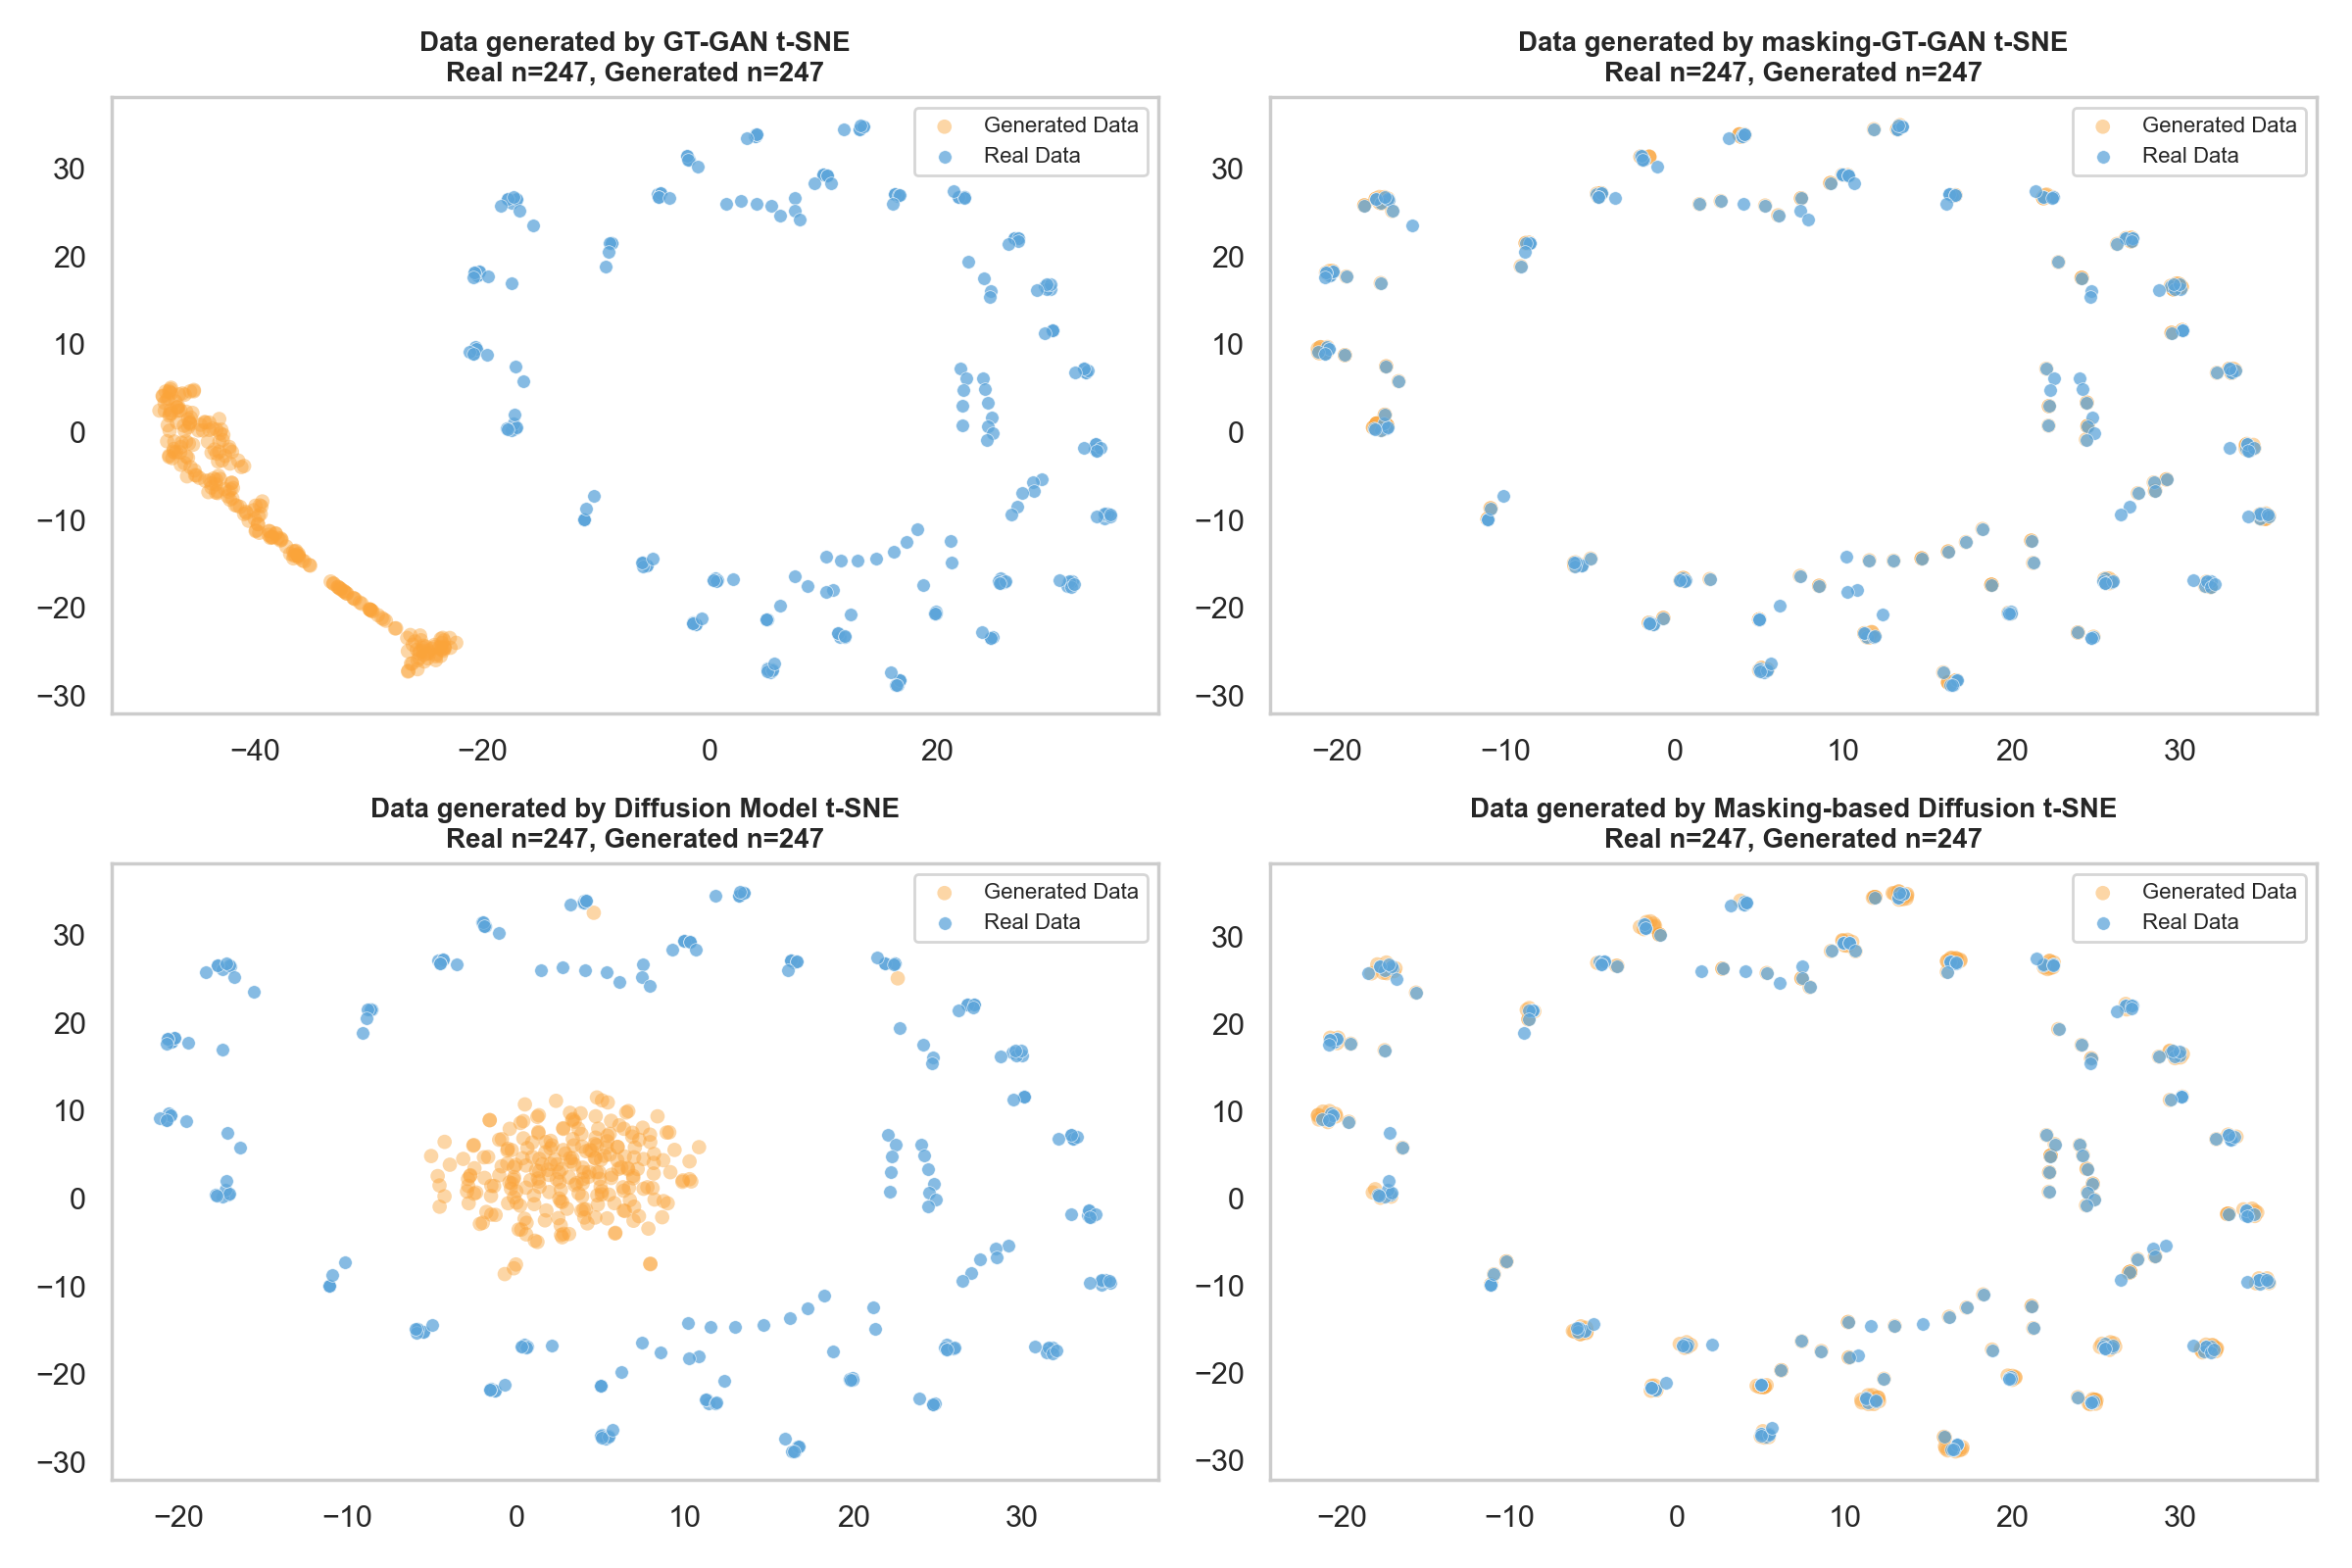

In [10]:
tsne_path = FIGURE_DIR / "tsne_2x2_real_vs_generated_full.png"
if tsne_path.exists():
    display(Image(filename=str(tsne_path)))
else:
    print("t-SNE figure not found:", tsne_path)


## 6. 다음 단계
 
 Research02를 새 data-driven adaptive structured masking 방식으로 재실행한 뒤, 같은 generated `.npz` 파일을 사용해 Research03, Research04, Research05를 순서대로 다시 실행한다.
 
 ```text
 Research02 -> Research03 -> Research04 -> Research05
 ```
